In [2]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[3, 6, 9, 11])

nb_name = "annotation.ipynb"

_compare_version(nb_name)

# Cell type annotation and marker list assembly
<hr style="border:2px solid black"> </hr>

## 1 - Description

**Requires a clustered or otherwise categorized anndata object. A clustering can be generated with a clustering notebook (e.g. `rna_analysis/notebooks/04_clustering.ipynb`).**

**Move this notebook into the notebook folder (e.g. `rna_analysis/notebooks/`) of the respective analysis before using it!**

This Jupyter Notebook is designed for annotating cell types in clustered AnnData objects. It is divided into two main parts:

- **Marker List Assembly**: This part is used when no existing marker lists are available. It enables users to assemble custom marker lists using the MarkerRepo.

- **Annotation**: This section applies the created or provided marker lists to annotate cell types in AnnData objects.


For more information about MarkerRepo, click [here](https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features).

--------------

## 2- Setup

In [3]:
from sctoolbox import settings
import sctoolbox.utils as utils
import sctoolbox.plotting as pl
import os
import pandas as pd
pd.set_option('display.max_columns', None)  # no limit to the number of columns shown

settings.settings_from_config("config.yaml", key="annoation")

[WARNING] Log file '../logs/annotation_log.txt' already exists. The file will be overwritten since 'overwrite_log' is set to True.
Created directory: ../tables/annotation/


In [4]:
try:
    import markerrepo.wrappers as wrap
    import markerrepo.marker_repo as mr
except ModuleNotFoundError:
    raise ModuleNotFoundError("Please install the latest MarkerRepo version.")
    
with pd.option_context("display.max.rows", None, "display.max_colwidth", None):
    display(utils.general.get_version_report(report="versions.yml"))

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


,Name,Version
0,Python,"3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]"
1,sctoolbox,NA
2,numpy,2.3.5
3,anndata,0.12.6
4,markerrepo,0.1
5,scanpy,1.11.5
6,pandas,2.3.3


<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [5]:
# Set inpput anndata
clustered_adata = "anndata_marker.h5ad"

___

## 3 - Loading adata

In [6]:
adata = utils.adata.load_h5ad(clustered_adata)

[INFO] The adata object was loaded from: ../adatas/anndata_marker.h5ad


In [7]:
with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)

AnnData object with n_obs × n_vars = 14558 × 23540
    obs: 'paper_cluster', 'filename', 'sample', 'timepoint', 'batch', 'Paper cell type', 'total_counts', 'log1p_total_counts', 'total_counts_is_mito', 'log1p_total_counts_is_mito', 'pct_counts_is_mito', 'total_counts_is_ribo', 'log1p_total_counts_is_ribo', 'pct_counts_is_ribo', 'doublet_score', 'predicted_doublet', 'predicted_sex', 'n_genes', 'log1p_n_genes', 'S_score', 'G2M_score', 'phase', 'leiden', 'LISI_score_X_pca', 'LISI_score_X_umap', 'phase_density', 'sample_density', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'leiden_1.6', 'leiden_1.7', 'leiden_1.8', 'leiden_1.9', 'clustering'
    var: 'gene_id', 'is_mito', 'is_ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means',

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes,S_score,G2M_score,phase,leiden,LISI_score_X_pca,LISI_score_X_umap,phase_density,sample_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,leiden_1.0,leiden_1.1,leiden_1.2,leiden_1.3,leiden_1.4,leiden_1.5,leiden_1.6,leiden_1.7,leiden_1.8,leiden_1.9,clustering
AAACCTGAGAGGTAGA-1,12,GSM5402436_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402436,14dpf,rep_1,Glia,944.0,6.851185,27.0,3.332205,2.860169,222.0,5.407172,23.516949,0.029984,False,Male,461,6.135565,-0.123526,-0.117125,G1,0,1.796906,1.638445,0.307508,0.390786,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
AAACCTGAGATCCTGT-1,8,GSM5402436_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402436,14dpf,rep_1,Cycling cells,6876.0,8.835938,170.0,5.141664,2.472368,3494.0,8.159089,50.814426,0.110244,False,Male,1380,7.230563,0.423172,0.098069,S,1,1.893098,1.992409,0.843049,0.651080,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTTGACGTT-2,8,GSM5402437_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402437,14dpf,rep_2,Cycling cells,8446.0,9.041567,115.0,4.753590,1.361591,3919.0,8.273847,46.400661,0.073171,False,Male,1642,7.404279,0.676872,-0.007470,S,3,1.949189,1.962102,0.597364,0.651307,3,2,2,2,3,4,7,8,4,4,18,9,19,10,19,19,10,20,21,8
TTTGTCATCGCGTAGC-2,8,GSM5402437_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402437,14dpf,rep_2,Cycling cells,6691.0,8.808668,147.0,4.997212,2.196981,2552.0,7.845025,38.140785,0.073171,False,Male,1838,7.516977,2.001291,0.296294,S,1,1.909246,1.559276,0.806784,0.672363,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


___

## 4 - Essential Input
<hr style="border:2px solid black"> </hr>
Adjust the parameters shown below to enable basic cell type annotation.

### 4.1 - Parameter Overview
<hr style="border:1px solid black"> </hr>

| Parameter | Description | Options |
|-----------|-------------|--------------|
| `clustering_column` | `.obs` column used for the cell type assignment. | `None` (select interactively) or String (e.g., `"leiden"`) |
| `organism` | Specifies the organism for marker list assembly (see `4.1.1`). None to provide a custom marker list (see `marker_lists`). | `None` or String (e.g., `"human"`) |
| `marker_lists` | Use preassembled marker lists. Either a path to a directory of marker lists, paths to marker lists or None to manually assemble one. See section `4.1.2` for details. | `None` or String or list of Strings (e.g., `"/path/my_markers"` or `["/heart_markers/markers", "/human/panglao"]` |
| `repo_path` | Path to MarkerRepo. if None, the MarkerRepo will be downloaded to the notebooks folder| `None` or String |

#### 4.1.1 Available organisms
The organism of the current dataset. Will be used to assemble a marker list based on the internally provided sources. 

Currently available organisms are:

- `human`

- `mouse`

- `zebrafish`

- `rat`
 
This parameter will be ignored in favor of a custom marker list (see section `4.1.2` below). This will also cause the assembly section (`5`) to be skipped.


#### 4.1.2 - Custom marker list
Alternatively, the user can supply a custom list of marker genes by setting `marker_lists` to a user-supplied file. This has to be a **delimited text file (`.csv`, `.tsv`, ...), without a header and with two columns**. The first column contains the marker names and the second column has the cell types. For example:
```
marker_1    Fibroblast
marker_2    Fibroblast
marker_3    Endocardium
...
```

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [8]:
# Annotation settings
clustering_column = "leiden_0.8"
organism = "zebrafish"
# set path to custom marker lists
marker_lists = None

# add the path to annotate_by_marker_and_features repo
# set to None to clone the repository to your notebooks folder
repo_path = None

# Data layer (advanced)
# decide which processing state of the data should be used for computation
# available layers can be seen above, e.g. "norm" to use normalized data
# it is recommended to use raw or normalized data for statistical testing
layer = "norm"

In [9]:
# check path of MarkerRepo
if repo_path is None or not os.path.exists(repo_path):
    if not os.path.exists("./annotate_by_marker_and_features"):
        print("MarkerRepo was not found! Cloning repository...")
        !git clone https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features.git
    else:
        print("MarkerRepo was found! Changing path to <./annotate_by_marker_and_features>")
    repo_path = "./annotate_by_marker_and_features"

MarkerRepo was not found! Cloning repository...
Cloning into 'annotate_by_marker_and_features'...
remote: Enumerating objects: 2433, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 2433 (delta 54), reused 0 (delta 0), pack-reused 2331 (from 1)
Receiving objects: 100% (2433/2433), 73.79 MiB | 8.50 MiB/s, done.
Resolving deltas: 100% (1523/1523), done.


--------------

## 5 - Marker List Assembly
<hr style="border:2px solid black"> </hr>

The marker list paths are stored in the <b>marker_lists</b> variable. They work as input for the actual cell type annotation of the next cell.

### 5.1 - Parameter Overview
<hr style="border:1px solid black"> </hr>

| Parameter | Description | Options |
|-----------|-------------|---------|
| `search_terms` | Search terms for the marker list assembly, targeting specific columns. | `None` or Dictionary (e.g., `{"Source": "panglao.se", "Tissue", "Heart"}`) |
| `list_format` | Additional parameters for marker list assembly. One marker list is created per dictionary. | `None` or List of dictionaries (e.g., `[{"style":"two_column", "file_name":"two_column"}, {"style":"score", "file_name":"score"}]`|

**Recommendation:** Set `search_terms` and `list_format` to `None` this enables an interactive guide to assemble the marker list. Manually setting `search_terms` and `list_format` is mostly intended for advanced users who already know what to search for.

#### 5.1.1 search_terms (advanced)
Each `key:value` pair will narrow the search in the marker list database to target specific lists, for example, setting `"Organism name": "human"` will ensure the use of marker lists relevant to the selected organism. Multiple search terms will be connected with a logical `AND` e.g. `"Organism name": "human", "Tissue": "blood"` will only consider human marker genes of blood during list assembly.

**Run the following cell to see available input(s) for `search_terms`.**

#### 5.1.2 list_format (advanced)
The `list_format` parameter decides the method and format of the resulting annotation list. Each dictionary entry will result in a marker list, which will be saved locally as a separate annotation list.

| Key | Value | Description |
|-----|-------|-------------|
| `file_name` | `None` or filename | The file where the finished list will be stored. Set `None` or skip entry to set the name interactively. |
| `style` | One of `two_column`, `score` or `ui` | The style of the marker lists. Either a minimal list of gene to cell type assignments (`two_column`), a list including a score (average count of a marker gene across all lists, to measure specificity of markers to a cell type) (`score`) or a list where each gene is weighted by the ubiquitousness index (see below). |

>[The] **ubiquitousness index** (UI), [...] is an indicator of how often the gene is expressed in cell clusters. UI takes values between 0 and 1. Values toward 1 indicate the gene is expressed in more cell clusters, indicating the gene to be involved in housekeeping tasks.

[Franzén et al., 2019](https://doi.org/10.1093/database/baz046)

**List of available inputs for `search_terms`**

In [10]:
if not marker_lists and not organism:
    raise ValueError("Please provide either <organism> or a path to custom marker list <marker_lists>")
if not marker_lists:
    df = mr.search_df(df=mr.combine_dfs(repo_path=repo_path), col_to_search="Organism name", search_terms=[f"+{organism.split(' ')[0]}"])
    print(f"* Possible keys for <column_specific_terms>:\n {df.columns.to_list()}\n")
    for col in df.columns[:12]:
        print(f"* Possible values for {col}: {df[col].dropna().drop_duplicates().to_list()}\n")

* Possible keys for <column_specific_terms>:
 ['List name', 'Marker type', 'Organism name', 'Taxonomy ID', 'Submitter name', 'List type', 'Source', 'tags_transferred', 'Email', 'Date', 'Tissue', 'Life stage', 'tags_age', 'tags_info', 'Marker', 'Info']

* Possible values for List name: ['Zebrafish_mito', 'zebrafish_embryo', 'zebrafish_embryo2', 'zebrafish_brain', 'zebrafish_eye', 'zebrafish_heart', 'zebrafish_pancreas_intestine', 'zebrafish_kidney', 'zebrafish_liver', 'zebrafish_muscle', 'zebrafish_ovary', 'zebrafish_skin', 'zebrafish_spleen', 'zebrafish_bladder', 'zebrafish_testis', 'zebrafish_cord_blood', 'zebrafish_lung', 'zebrafish_cellcycle_genes', 'zebrafish_mito_genes', 'zebrafish_cranial_neural_crest_150dpf', 'zebrafish_cranial_neural_crest_1.5dpf', 'zebrafish_cranial_neural_crest_14dpf', 'zebrafish_non_cranial_neural_crest', 'zebrafish_non_mesenchymal_cranial_neural_crest', 'heart_tarasco']

* Possible values for Marker type: ['Genes']

* Possible values for Organism name: ['ze

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [11]:
# Marker list assembly
if not marker_lists:
    search_terms = {"Organism name": organism, 
                    "List name": ["zebrafish_cranial_neural_crest_14dpf",
                                  "zebrafish_non_cranial_neural_crest",
                                  "zebrafish_non_mesenchymal_cranial_neural_crest"]
                   }

    list_format = [{"file_name":"symbol", "style":"two_column"}, 
                   {"file_name":"score", "style":"score"},
                   {"file_name":"ui", "style":"ui"}
                  ]

___

In [12]:
if not marker_lists:
    marker_lists = wrap.create_multiple_marker_lists(
        cml_parameters=list_format,
        repo_path=repo_path,
        organism=organism,
        ensembl=mr.check_ensembl(adata),
        column_specific_terms=search_terms,
        show_lists=True,
        path=settings.table_dir
    )

Found 25 marker lists for the given organism zebrafish.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Email,Date,Tissue,Life stage,tags_age,tags_info,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745542877159,Zebrafish_mito,Genes,zebrafish,7955,"Kessler, Micha Frederick",Mitochondrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[NC_002333.13, ENSDARG00000081938, MT-ND4, ENS...",[mito]
1704948866343881,zebrafish_embryo,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,"[HOXB13A, ENSDARG00000056015, RFESD, ENSDARG00...","[Hatching gland, Lens, stromal cell, Keratinoc..."
1704949706689035,zebrafish_embryo2,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,"[RTN1B, ENSDARG00000021143, MARCKSL1B, ENSDARG...","[Hatching gland, Keratinocyte_krt1-19d high, N..."
1704950385309273,zebrafish_brain,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,brain,NaN,NaN,NaN,"[LACC1, ENSDARG00000076914, RTN1B, ENSDARG0000...","[Oligodendrocyte_sla high, Radial glia_mdkb hi..."
1704950859567107,zebrafish_eye,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,eye,NaN,NaN,NaN,"[SI:CH211-226H7.5, ENSDARG00000074150, SI:CH21...","[Müller glia, Stromal cell, Mt_rich cell, Kera..."
1704951711968568,zebrafish_heart,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,heart,NaN,NaN,NaN,"[LACC1, ENSDARG00000076914, MAP3K14A, ENSDARG0...","[Mt_rich cell, Smooth muscle cell, Fibroblast ..."
1704951902892390,zebrafish_pancreas_intestine,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,pancreas\nintestine,NaN,NaN,NaN,"[IGIC1S1, ENSDARG00000093272, ACSL5, ENSDARG00...","[Macrophage, Pancreatic epsilon cell, Intestin..."
1704952096274898,zebrafish_kidney,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,kidney,NaN,NaN,NaN,"[RPL29, ENSDARG00000077717, MARCKSL1B, ENSDARG...","[Mucin cell, Erythrocyte, Nephron epithelial c..."
1704952524756597,zebrafish_liver,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,liver,NaN,NaN,NaN,"[MARCKSL1B, ENSDARG00000035715, ZGC:198329, EN...","[Endothelial cell, Biliary epithelial cell, En..."


Found 3 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Email,Date,Tissue,Life stage,tags_age,tags_info,Marker,Info
ID,,,,,,,,,,,,,,,,
1741686677329305,zebrafish_cranial_neural_crest_14dpf,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,NaN,cranial neural crest,child,14 dpf,NaN,"[HYAL4, ENSDARG00000051823, UCMAA, ENSDARG0000...","[Perichondrium, Hyaline cartilage, Gill progen..."
1741687334852231,zebrafish_non_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,NaN,cranial neural crest,NaN,NaN,non cranial neural crest,"[EPCAM, ENSDARG00000040534, HBBE2, ENSDARG0000...","[Epithelia, Blood]"
1741687684295404,zebrafish_non_mesenchymal_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,NaN,cranial neural crest,NaN,NaN,non-mesenchymal cranial neural crest derivatives,"[ZWI, ENSDARG00000101826, STMN1B, ENSDARG00000...","[Otic cells, Melanocytes, Neuronal, Xanthophor..."


Preparing two column style marker list...
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/05-14dpf/tables/annotation/symbol
Found 25 marker lists for the given organism zebrafish.


...

Preparing score style marker list...
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/05-14dpf/tables/annotation/score
Found 25 marker lists for the given organism zebrafish.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Email,Date,Tissue,Life stage,tags_age,tags_info,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745542877159,Zebrafish_mito,Genes,zebrafish,7955,"Kessler, Micha Frederick",Mitochondrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[NC_002333.13, ENSDARG00000081938, MT-ND4, ENS...",[mito]
1704948866343881,zebrafish_embryo,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,"[HOXB13A, ENSDARG00000056015, RFESD, ENSDARG00...","[Hatching gland, Lens, stromal cell, Keratinoc..."
1704949706689035,zebrafish_embryo2,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,"[RTN1B, ENSDARG00000021143, MARCKSL1B, ENSDARG...","[Hatching gland, Keratinocyte_krt1-19d high, N..."
1704950385309273,zebrafish_brain,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,brain,NaN,NaN,NaN,"[LACC1, ENSDARG00000076914, RTN1B, ENSDARG0000...","[Oligodendrocyte_sla high, Radial glia_mdkb hi..."
1704950859567107,zebrafish_eye,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,eye,NaN,NaN,NaN,"[SI:CH211-226H7.5, ENSDARG00000074150, SI:CH21...","[Müller glia, Stromal cell, Mt_rich cell, Kera..."
1704951711968568,zebrafish_heart,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,heart,NaN,NaN,NaN,"[LACC1, ENSDARG00000076914, MAP3K14A, ENSDARG0...","[Mt_rich cell, Smooth muscle cell, Fibroblast ..."
1704951902892390,zebrafish_pancreas_intestine,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,pancreas\nintestine,NaN,NaN,NaN,"[IGIC1S1, ENSDARG00000093272, ACSL5, ENSDARG00...","[Macrophage, Pancreatic epsilon cell, Intestin..."
1704952096274898,zebrafish_kidney,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,kidney,NaN,NaN,NaN,"[RPL29, ENSDARG00000077717, MARCKSL1B, ENSDARG...","[Mucin cell, Erythrocyte, Nephron epithelial c..."
1704952524756597,zebrafish_liver,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,liver,NaN,NaN,NaN,"[MARCKSL1B, ENSDARG00000035715, ZGC:198329, EN...","[Endothelial cell, Biliary epithelial cell, En..."


Found 3 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Email,Date,Tissue,Life stage,tags_age,tags_info,Marker,Info
ID,,,,,,,,,,,,,,,,
1741686677329305,zebrafish_cranial_neural_crest_14dpf,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,NaN,cranial neural crest,child,14 dpf,NaN,"[HYAL4, ENSDARG00000051823, UCMAA, ENSDARG0000...","[Perichondrium, Hyaline cartilage, Gill progen..."
1741687334852231,zebrafish_non_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,NaN,cranial neural crest,NaN,NaN,non cranial neural crest,"[EPCAM, ENSDARG00000040534, HBBE2, ENSDARG0000...","[Epithelia, Blood]"
1741687684295404,zebrafish_non_mesenchymal_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,NaN,cranial neural crest,NaN,NaN,non-mesenchymal cranial neural crest derivatives,"[ZWI, ENSDARG00000101826, STMN1B, ENSDARG00000...","[Otic cells, Melanocytes, Neuronal, Xanthophor..."


Preparing ui style marker list...
Directory does not exist. Cloning the whitelist repository...
Repository cloned.
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/05-14dpf/tables/annotation/ui


--------------

## 6 - Annotate adata
<hr style="border:2px solid black"> </hr>
After selection and creation of the gene marker lists, potential cell types can be annotated in this final step. This notebook supports two methods of annotation, MarkerRepo and SCSA.

### 6.1 - Parameter Overview

| Parameter | Description | Options/Type |
|-----------|-------------|--------------|
| `marker_repo` | Use [MarkerRepo](https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features) for annotation. | Boolean |
| `SCSA` | Use [SCSA](https://github.com/bioinfo-ibms-pumc/SCSA) for annotation. | Boolean |
| `mr_obs` | Prefix of the MarkerRepo annotation columns added to `anndata.obs`. | String (e.g., "mr") |
| `scsa_obs` | Prefix of the SCSA annotation columns added to `anndata.obs`. | String (e.g., "scsa") |
| `rank_genes_column` | **Advanced users only** Column of `.uns` table with rank genes scores. If `None`, the ranking will be performed on the clustering_column. | `None` or String |
| `reference_obs` | A reference annotation in `.obs` for comparison. See section `3 - Loading adata` for possible values. | `None` or String |
| `min_hits` | The minimum number of marker matches needed to annotate a cluster. May be lowered in case of small marker lists. | Integer |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [13]:
marker_repo = True
SCSA = True
mr_obs = "MR"
scsa_obs = "SCSA"
rank_genes_column = None
reference_obs = "Paper cell type"
min_hits = 1

___

In [14]:
compare_df = wrap.run_annotation(adata,
                                 marker_repo=marker_repo,
                                 SCSA=SCSA,
                                 marker_lists=marker_lists,
                                 mr_obs=mr_obs,
                                 scsa_obs=scsa_obs,
                                 rank_genes_column=rank_genes_column,
                                 clustering_column=clustering_column,
                                 reference_obs=reference_obs,
                                 show_comparison=True,
                                 ignore_overwrite=True,
                                 show_plots=False,
                                 output_path=settings.table_dir,
                                 min_hits=min_hits
                                )
_ = pl.general.plot_table(compare_df, crop=None, report='01_Comparison_of_cell_type_annotations.png', col_width=7)

Comparison of cell type annotations:


,Paper cell type,MR_symbol_leiden_0.8,SCSA_symbol_leiden_0.8,MR_score_leiden_0.8,SCSA_score_leiden_0.8,MR_ui_leiden_0.8,SCSA_ui_leiden_0.8
leiden_0.8,,,,,,,
1,Glia,Glia,Glia,Glia,Glia,Glia,Glia
2,Cycling cells,Tendon/ligament,Teeth,Tendon/ligament,Teeth,Tendon/ligament,Teeth
3,Mesenchyme,Stroma,Stroma,Stroma,Stroma,Stroma,Stroma
4,Mesenchyme,Stroma,Teeth,Dermal fibroblast,Teeth,Dermal fibroblast,Teeth
5,Mesenchyme,Stroma,Perivascular,Perivascular,Perivascular,Perivascular,Perivascular
6,Mesenchyme,Stroma,Stroma,Stroma,Stroma,Stroma,Stroma
7,Neuronal,Neuronal,Melanocytes,Neuronal,Melanocytes,Neuronal,Melanocytes
8,Mesenchyme,Dermal fibroblast,Mesenchyme,Dermal fibroblast,Mesenchyme,Dermal fibroblast,Mesenchyme
9,Mesenchyme,Gill stroma,Gill progenitor,Gill progenitor,Gill progenitor,Gill progenitor,Gill progenitor


[INFO] Saving figure to ../figures/annotation/marker_genes_dots_leiden_0.8.pdf


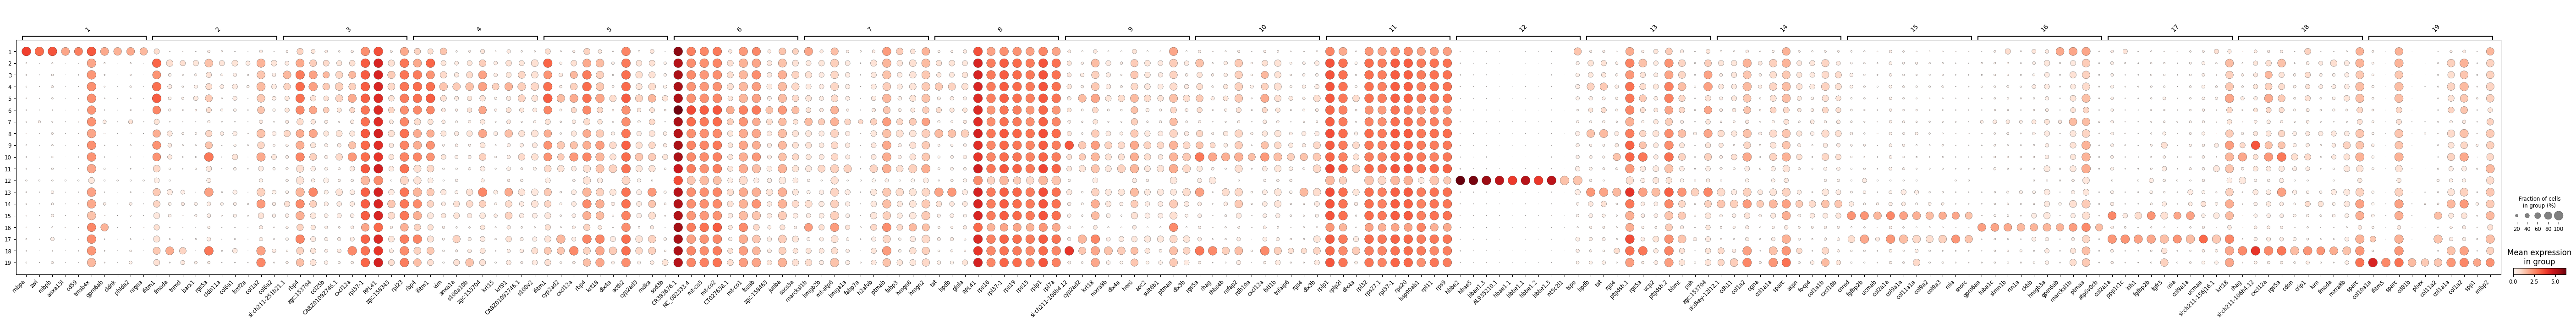

In [15]:
if not rank_genes_column:
    rank_genes_column = f"rank_genes_groups_{clustering_column}"

# Plot dotplot of markers
_ = pl.marker_genes.rank_genes_plot(
    adata,
    key=rank_genes_column,
    n_genes=10,
    style="dots",
    save=f"marker_genes_dots_{clustering_column}.pdf",
    layer=layer,
    report=f"01_marker_genes_dots_{clustering_column}.png"
)

[INFO] Saving figure to ../figures/annotation/compare_annotations.pdf


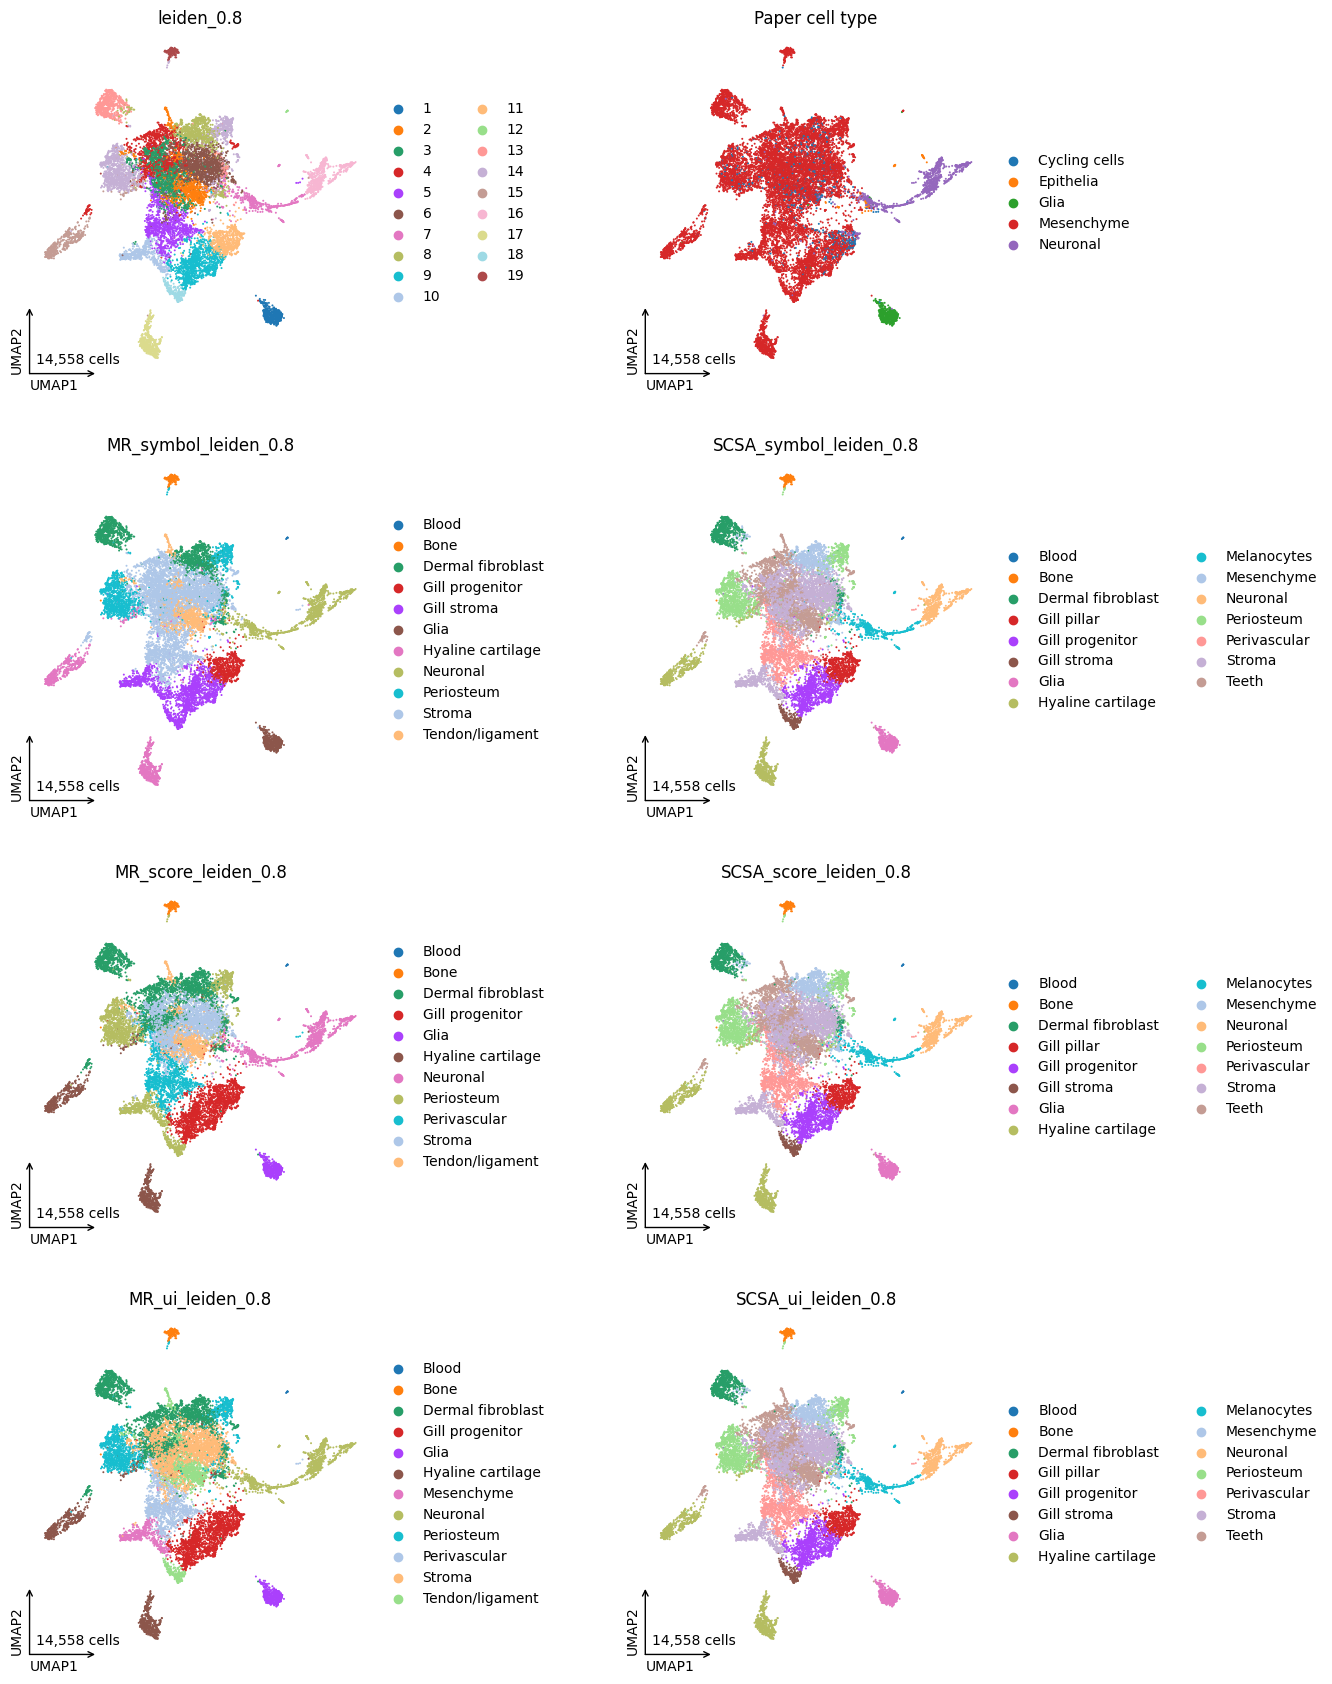

In [16]:
# Plot cell type annotations
columns = [clustering_column] + list(compare_df.columns)
_ = pl.embedding.plot_embedding(adata, method="umap", color=columns, ncols=2,
                                save="compare_annotations.pdf", report="02_compare_annotations.png")

--------------

### 6.1 - Show annotated .obs table

In [17]:
display(adata.obs)

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes,S_score,G2M_score,phase,leiden,LISI_score_X_pca,LISI_score_X_umap,phase_density,sample_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,leiden_1.0,leiden_1.1,leiden_1.2,leiden_1.3,leiden_1.4,leiden_1.5,leiden_1.6,leiden_1.7,leiden_1.8,leiden_1.9,clustering,MR_symbol_leiden_0.8,SCSA_symbol_leiden_0.8,MR_score_leiden_0.8,SCSA_score_leiden_0.8,MR_ui_leiden_0.8,SCSA_ui_leiden_0.8
AAACCTGAGAGGTAGA-1,12,GSM5402436_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402436,14dpf,rep_1,Glia,944.0,6.851185,27.0,3.332205,2.860169,222.0,5.407172,23.516949,0.029984,False,Male,461,6.135565,-0.123526,-0.117125,G1,0,1.796906,1.638445,0.307508,0.390786,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,Glia,Glia,Glia,Glia,Glia,Glia
AAACCTGAGATCCTGT-1,8,GSM5402436_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402436,14dpf,rep_1,Cycling cells,6876.0,8.835938,170.0,5.141664,2.472368,3494.0,8.159089,50.814426,0.110244,False,Male,1380,7.230563,0.423172,0.098069,S,1,1.893098,1.992409,0.843049,0.651080,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,Tendon/ligament,Teeth,Tendon/ligament,Teeth,Tendon/ligament,Teeth
AAACCTGAGCGATTCT-1,3,GSM5402436_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402436,14dpf,rep_1,Mesenchyme,4346.0,8.377241,36.0,3.610918,0.828348,2073.0,7.637234,47.699036,0.023206,False,Male,994,6.902743,-0.135613,-0.059756,G1,7,1.596258,1.994145,0.264279,0.323099,5,3,4,8,6,5,9,9,11,8,13,11,15,15,13,13,11,13,10,9,Gill stroma,Gill progenitor,Gill progenitor,Gill progenitor,Gill progenitor,Gill progenitor
AAACCTGAGCTCCTCT-1,9,GSM5402436_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402436,14dpf,rep_1,Mesenchyme,5921.0,8.686430,65.0,4.189655,1.097787,2454.0,7.805882,41.445702,0.062025,False,Male,1298,7.169350,-0.079223,-0.114112,G1,11,1.856424,1.943796,0.263807,0.235100,3,4,6,6,8,8,8,13,13,12,17,13,18,4,18,17,14,19,13,13,Dermal fibroblast,Dermal fibroblast,Dermal fibroblast,Dermal fibroblast,Dermal fibroblast,Dermal fibroblast
AAACCTGAGGAGTTTA-1,14,GSM5402436_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402436,14dpf,rep_1,Neuronal,1976.0,7.589336,42.0,3.761200,2.125506,739.0,6.606650,37.398785,0.034604,False,Male,711,6.568078,-0.006221,-0.023388,G1,12,1.881717,1.950910,0.132027,0.203869,2,6,5,9,5,9,11,7,14,13,12,10,10,5,6,18,15,21,14,7,Neuronal,Melanocytes,Neuronal,Melanocytes,Neuronal,Melanocytes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCGCGTGT-2,6,GSM5402437_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402437,14dpf,rep_2,Mesenchyme,876.0,6.776507,43.0,3.784190,4.908676,215.0,5.375278,24.543379,0.179856,False,Male,409,6.016157,-0.144181,-0.043329,G1,18,1.475703,1.967483,0.544599,0.534768,3,3,4,4,7,7,4,6,19,19,20,19,4,22,16,26,16,26,31,6,Stroma,Stroma,Stroma,Stroma,Stroma,Stroma
TTTGTCAGTGCATCTA-2,7,GSM5402437_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402437,14dpf,rep_2,Mesenchyme,3723.0,8.222553,36.0,3.610918,0.966962,1447.0,7.277938,38.866505,0.034869,False,Male,1108,7.011214,-0.197856,-0.120894,G1,2,1.819466,1.930955,0.979955,0.981641,3,2,2,2,4,3,3,4,3,3,2,5,13,9,10,11,4,8,20,4,Stroma,Teeth,Dermal fibroblast,Teeth,Dermal fibroblast,Teeth
TTTGTCAGTGGGTATG-2,6,GSM5402437_scRNAseq_Sox10_Cre_bact_BtR_14dpf_r...,GSM5402437,14dpf,rep_2,Mesenchyme,4352.0,8.378620,39.0,3.688879,0.896140,1558.0,7.351800,35.799633,0.034869,False,Male,1068,6.974479,-0.130005,-0.028503,G1,13,1.925608,1.994284,0.420968,0.381358,3,2,2,2,2,4,2,2,2,14,9,24,3,6,7,9,7,6,9,2,Tendon/ligament,Teeth,Tendon/ligament,Teeth,Tendon/ligament,Teeth
TTTGTCAGTTGACGTT-2,8,GSM5402437_scRNAseq_Sox

In [18]:
# compare annotations to paper
paper_markers = {
    # non-cncc
    'Blood': ['hbbe2'],
    'Epithelia': ['epcam'],
    # non-mesenchymal cncc derivatives
    'Glia': ['zwi'],
    'Neuronal': ['neurod1', 'neurod2', 'neurod4', 'neurod6a', 'neurod6b', 'stmn1b'],
    'Otic cells': ['atoh1a'],
    'Melanocytes': ['mitfa'],
    'Iridophores': ['tfec'],
    'Xantophore': ['aox5'],
    # 14 dpf
    'Perichondrium': ['hyal4', 'mafa'],
    'Periosteum': ['postnb', 'aspn' , 'mmp2'],
    'Dermal fibroblast': ['hpdb'],
    'Mesenchyme': ['alx4a', 'msx1b', 'prrx1b'],
    'Stroma': ['cxcl12a', 'ccl25b'],
    'Teeth': ['spock3', 'lhx8a', 'postna'],
    'Hyaline cartilage': ['col2a1a', 'acana', 'ucmab'],
    'Gill stroma': ['gata3', 'cxcl12a'],
    'Gill progenitor': ['gata3', 'fgf10b'],
    'Gill cartilage': ['ucmaa'],
    'Gill pillar': ['gata3', 'ncam3'],
    'Perivascular': ['acta2', 'tagln', 'myh11a'],
    'Bone': ['spp1', 'ifitm5'],
    'Tendon/ligament': ['scxa', 'tnmd', 'thbs4a']
}

[INFO] Saving figure to ../figures/annotation/marker_repo_score_annotation_vs_paper_markers_dotplot.png


{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

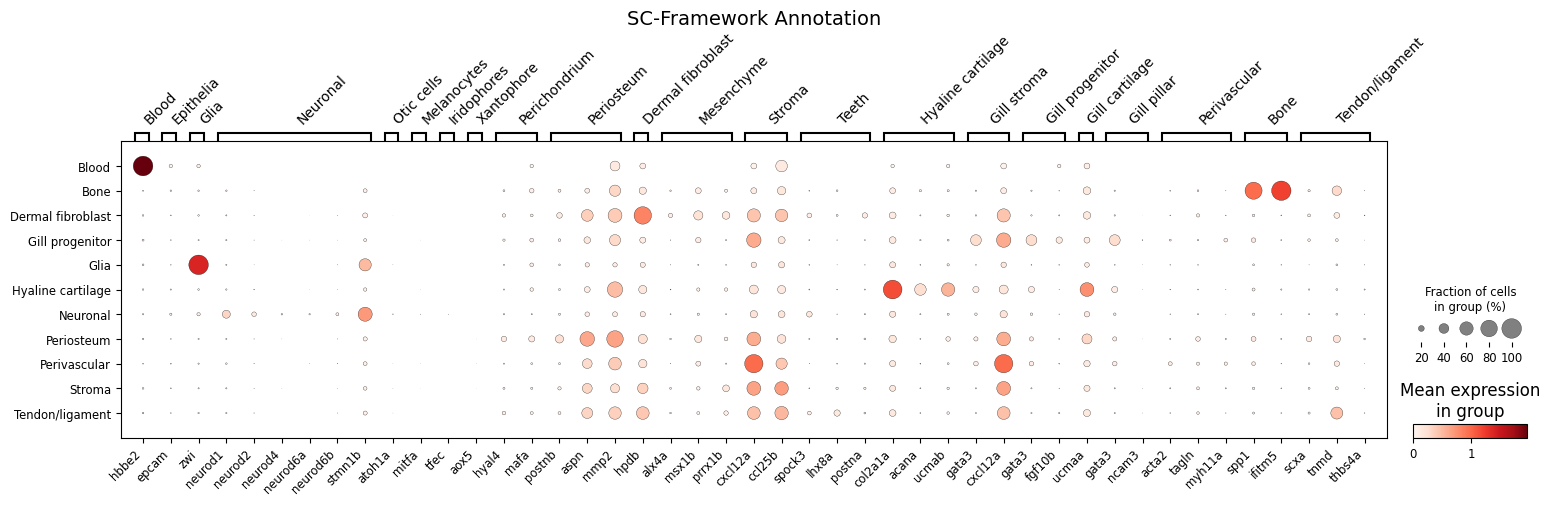

In [19]:
pl.marker_genes.rank_genes_plot(
    adata=adata,
    groupby="MR_score_leiden_0.8",
    genes=paper_markers,
    log=True,
    title="SC-Framework Annotation",
    save="marker_repo_score_annotation_vs_paper_markers_dotplot.png"
)

[INFO] Saving figure to ../figures/annotation/fabian_et_al_annotation_vs_paper_markers_dotplot.png


{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

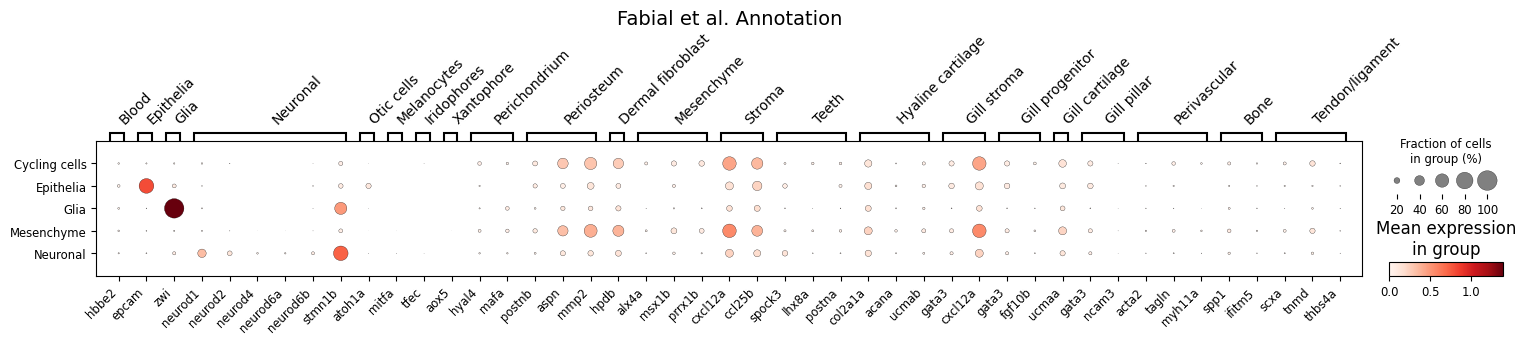

In [20]:
pl.marker_genes.rank_genes_plot(
    adata=adata,
    groupby="Paper cell type",
    genes=paper_markers,
    log=True,
    title="Fabial et al. Annotation",
    save="fabian_et_al_annotation_vs_paper_markers_dotplot.png"
)

--------------

## 7 - Save adata

In [21]:
utils.io.update_yaml({"annotation": True}, "method.yml", path_prefix="report")
utils.adata.save_h5ad(adata, "anndata_annotated.h5ad")

[WARNING] Found '/' in .uns['sctoolbox']['log']['rank_genes_plot']['run_23']['kwargs']['genes']['Tendon/ligament'], which is prohibited as of anndata>=0.12. Replacing with '|'.
[INFO] The adata object was saved to: ../adatas/anndata_annotated.h5ad
